***
# Notes
***

1. still need to bring in lag price feature
2. hyper tuning has got from 70% to >90% accuracy
    - `max_depth` is higher than usual; need justification for this
    - `learning_rate` is high (supposedly) aswell
    - still an issue around predicting 0 values (see `Actual v Predicted graph`) 

***

In [1]:
import dataset
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

seed = 123

df = dataset.read_agg(month_start=1, month_end=12)
df = df[df['pickup_year'] == 2024]

/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:276: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:277: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 2887808 entries, 10 to 2887836
Data columns (total 46 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   pickup_year            int32         
 1   pickup_month           int32         
 2   pickup_week            UInt32        
 3   pickup_day             int32         
 4   pickup_date            datetime64[ns]
 5   pickup_dow             int32         
 6   pickup_service_zone    category      
 7   pickup_zone            object        
 8   dropoff_service_zone   category      
 9   dropoff_zone           object        
 10  route                  object        
 11  service_route          category      
 12  vendor                 object        
 13  total_ride_count       int64         
 14  total_passenger_count  float64       
 15  avg_passenger_count    float64       
 16  total_trip_distance    float64       
 17  avg_trip_distance      float64       
 18  total_fare_amount      flo

# Preprocess

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category
# Not sure why this changes from typecasting in `dataset.clean()`
df = df.astype({
    'vendor': 'category',
    # 'ratecode': 'category',
    'pickup_zone': 'category',
    'dropoff_zone': 'category',
    'route': 'category',
    'fog': 'bool',  
    'low_vis': 'bool',  
    'thunder': 'bool',  
    'hail': 'bool',  
    'freezing_rain': 'bool',  
    'haze': 'bool',
    'holiday': 'category',
})

# Remove waste columns
df = df.drop(errors='ignore', columns=[
    # 'pickup_zone',
    # 'dropoff_zone',
    'pickup_date',
    'service_route',
    'pickup_service_zone',
    'dropoff_service_zone',
    'pickup_week',
    'pickup_day',
    'total_passenger_count',  
    'avg_passenger_count',    
    'total_trip_distance',    
    'avg_trip_distance',      
    'total_fare_amount',      
    'avg_fare_amount',        
    'total_extra',            
    'avg_extra',              
    'total_mta_tax',          
    'avg_mta_tax',            
    'total_tip_amount',       
    'avg_tip_amount',         
    'total_tolls_amount',     
    'avg_tolls_amount',       
    'total_impr_surcharge',
    'avg_impr_surcharge',     
    'total_revenue',          
    'avg_revenue',            
    'total_airport_fee',      
    'avg_airport_fee',       
])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2887808 entries, 10 to 2887836
Data columns (total 20 columns):
 #   Column            Dtype   
---  ------            -----   
 0   pickup_year       int32   
 1   pickup_month      int32   
 2   pickup_dow        int32   
 3   pickup_zone       category
 4   dropoff_zone      category
 5   route             category
 6   vendor            category
 7   total_ride_count  int64   
 8   temp_high         float64 
 9   precip            float64 
 10  snow              float64 
 11  max_wind_speed    float64 
 12  cloud_coverage    float64 
 13  fog               bool    
 14  low_vis           bool    
 15  thunder           bool    
 16  hail              bool    
 17  freezing_rain     bool    
 18  haze              bool    
 19  holiday           category
dtypes: bool(6), category(5), float64(5), int32(3), int64(1)
memory usage: 223.7 MB


In [3]:
# Onehot encode the following:
#
#  4   pickup_service_zone    category
#  5   pickup_zone            category  
#  6   dropoff_service_zone   category
#  7   dropoff_zone           category  
#  8   route                  category  
#  9   service_route          category  
#  10  vendor                 category  
#  11  ratecode               category  [NOT USED]
#  12  payment_type           category  [NOT USED]
#
# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    # 'pickup_service_zone',
    # 'dropoff_service_zone',
    # 'service_route',
    'vendor',
    'pickup_dow',
    # 'ratecode',
    # 'payment_type',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'dropoff_zone',
    'route',
    'holiday'
]

# Split `y` BEFORE pipeline
y = df['total_ride_count']
X = df.drop(columns=['total_ride_count'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # DEPRECATED: returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

# Train

In [30]:
# Comments sourced from: <https://xgboost.readthedocs.io/en/stable/parameter.html>

# Fine-tuning workflow:
#
# 1. max_depth increased from 6 -> 10 and n_estimators increased from 
# 2. set reg_lambda=2; to penalise overreliance on routes & zones  [NO EFFECT]
# 3. set reg_alpha=1; to reduce importance of unimportant features [NO EFFECT]
# 4. set min_child_weight=2; trying to kill weird cluster near 0 values [NO EFFECT]
# 5. set scale_pos_weight=3 [NEGATIVE EFFECT]
# 6. set eval_metric="mae" instead of mean squared err [NO EFFECT]
xg = XGBRegressor(
    n_estimators=700,
    learning_rate=0.2,

    # Maximum depth of a tree. Increasing this value will make the model more complex 
    # and more likely to overfit. 0 indicates no limit on depth. 
    #
    # Beware that XGBoost aggressively consumes memory when training a deep tree.
    max_depth=10,

    # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, 
    # the more conservative the algorithm will be. 
    # 
    # Note that a tree where no splits were made might still contain a single terminal node with a non-zero score. 
    min_split_loss=0, # default = 0

    # L2 regularization term on weights. 
    # 
    # Increasing this value will make model more conservative.
    reg_lambda=2, # default = 0

    # L1 regularization term on weights. 
    # 
    # Increasing this value will make model more conservative.
    reg_alpha=1, # default = 0

    # Control the balance of positive and negative weights, useful for unbalanced classes. 
    # 
    # A typical value to consider: sum(negative instances) / sum(positive instances).
    scale_pos_weight=1, # default = 1

    # Minimum sum of instance weight (hessian) needed in a child. If the tree partition 
    # step results in a leaf node with the sum of instance weight less than min_child_weight, 
    # then the building process will give up further partitioning. 
    # 
    # In linear regression task, this simply corresponds to minimum number of instances 
    # needed to be in each node. 
    # 
    # The larger min_child_weight is, the more conservative the algorithm will be.
    min_child_weight=1, # default = 1

    # Evaluation metrics for validation data, a default metric will be assigned 
    # according to objective (rmse for regression, and logloss for classification, 
    # mean average precision for rank:map, etc.)
    eval_metric="mae", # default = "rmse"

    random_state=seed
)

xg.fit(
    X_train, y_train,

    # If model fails to improve on the validation set for 50 rounds, just stop
    # early_stopping_rounds=50, 
    # eval_set=[(X_val, y_val)],

    # Print report on training process
    verbose=100,    
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mae'


Mean Absolute Error: 	2.7071
Mean Squared Error: 	27.6657
R squared: 		0.9560


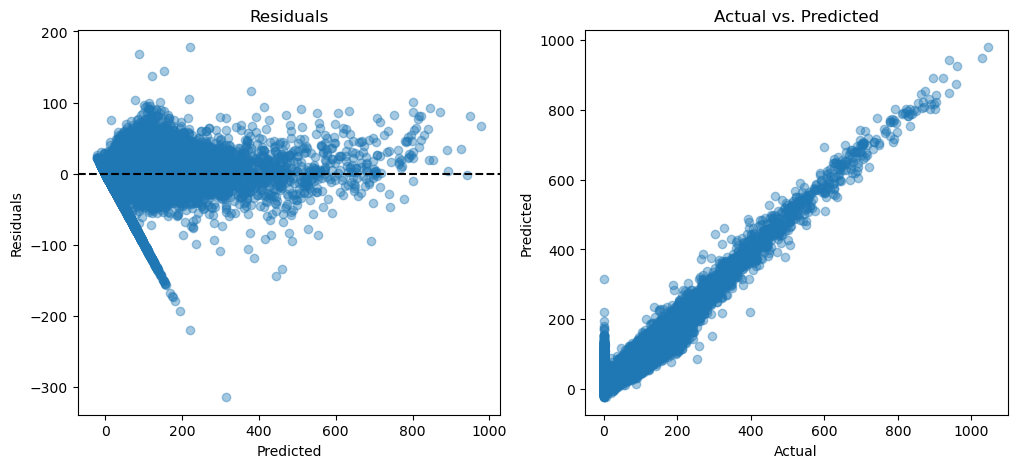

In [31]:
import helpers

training_predictions = xg.predict(X_train)
helpers.analysis(y_train, training_predictions)

Mean Absolute Error: 	3.2695
Mean Squared Error: 	44.1515
R squared: 		0.9308


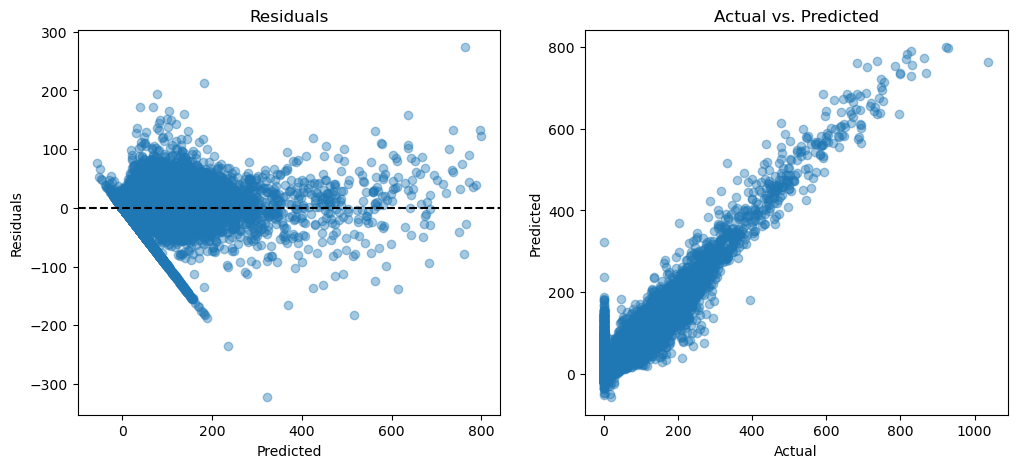

In [32]:
validation_predictions = xg.predict(X_val)
helpers.analysis(y_val, validation_predictions)

                                             feature  importance
1                  onehot__vendor_Curb Mobility, LLC    0.635322
11                             ordinal__dropoff_zone    0.090328
10                              ordinal__pickup_zone    0.078410
9                               onehot__pickup_dow_6    0.038758
12                                    ordinal__route    0.038131
8                               onehot__pickup_dow_5    0.025326
0   onehot__vendor_Creative Mobile Technologies, LLC    0.014751
3                               onehot__pickup_dow_0    0.007262
22                                remainder__low_vis    0.007124
13                                  ordinal__holiday    0.006779
4                               onehot__pickup_dow_1    0.005854
15                           remainder__pickup_month    0.005832
5                               onehot__pickup_dow_2    0.005626
7                               onehot__pickup_dow_4    0.005394
6                        

<Figure size 1200x1200 with 0 Axes>

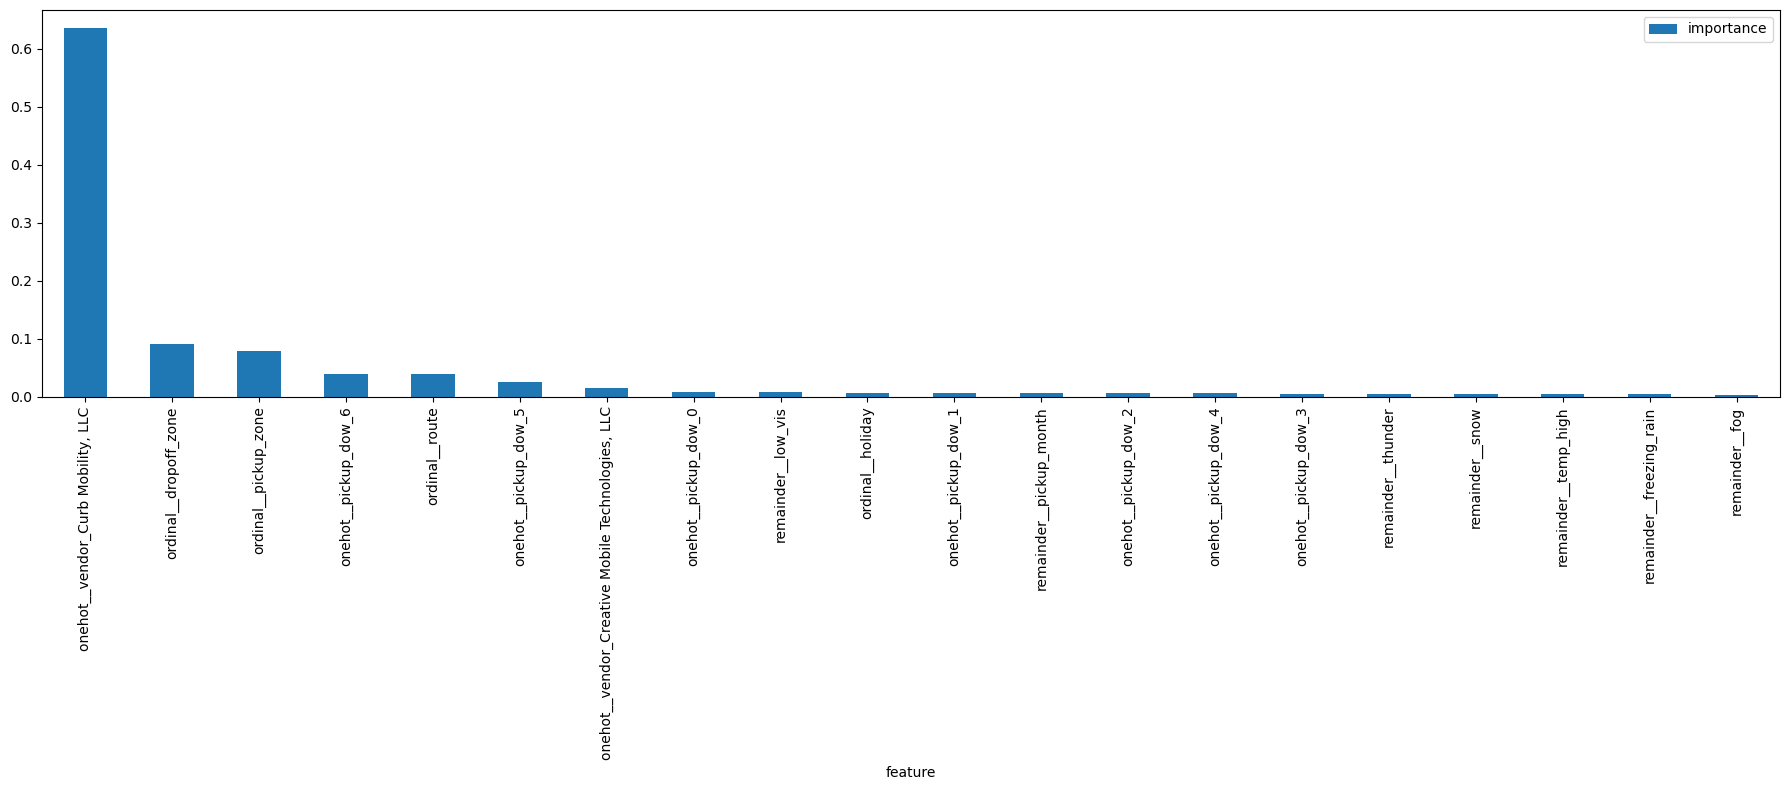

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = pipeline.get_feature_names_out()
importances = xg.feature_importances_
feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feat_df)

plt.figure(figsize=(12,12))
feat_df.head(20).plot(kind='bar', x='feature', y='importance', figsize=(18, 8))
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

# Test

Mean Absolute Error: 	3.2711
Mean Squared Error: 	45.2833
R squared: 		0.9315


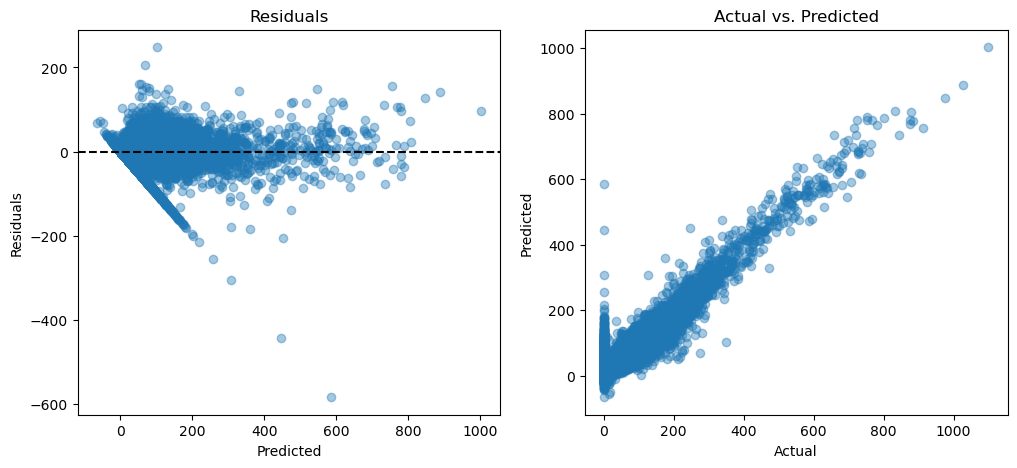

In [35]:
test_predictions = xg.predict(X_test)
helpers.analysis(y_test, test_predictions)